In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = {
    'customers': pd.read_csv('../../cleaned_data/customers.csv'),
    'orders': pd.read_csv('../../cleaned_data/orders.csv'),
    'order_items': pd.read_csv('../../cleaned_data/order_items.csv'),
    'payments': pd.read_csv('../../cleaned_data/payments.csv'),
    'reviews': pd.read_csv('../../cleaned_data/reviews.csv'),
    'products': pd.read_csv('../../cleaned_data/products.csv'),
    'sellers': pd.read_csv('../../cleaned_data/sellers.csv'),
    'geolocation': pd.read_csv('../../cleaned_data/geolocation.csv'),
}

df['orders']['order_delivered_customer_date'] = pd.to_datetime(df['orders']['order_delivered_customer_date'])
df['orders']['order_estimated_delivery_date'] = pd.to_datetime(df['orders']['order_estimated_delivery_date'])
df['orders']['order_purchase_timestamp'] = pd.to_datetime(df['orders']['order_purchase_timestamp'])

analysis = (
    df['order_items']
    .merge(df['orders'], on='order_id', how='inner')
    .merge(df['customers'], on='customer_id', how='inner')
    .merge(df['products'], on='product_id', how='inner')
    .merge(df['sellers'], on='seller_id', how='inner')
    .merge(df['reviews'][['order_id', 'review_score']], on='order_id', how='left')
)

analysis['delivery_delay_days'] = (
    analysis['order_delivered_customer_date'] - analysis['order_estimated_delivery_date']
).dt.days

analysis['delivery_time_days'] = (
    analysis['order_delivered_customer_date'] - analysis['order_purchase_timestamp']
).dt.days

analysis['order_month'] = analysis['order_purchase_timestamp'].dt.to_period('M').astype(str)


TASK 1:

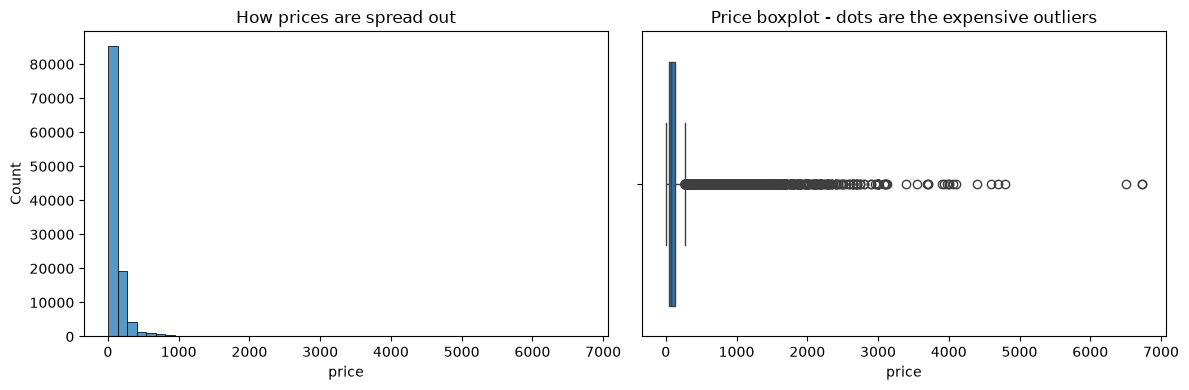

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(analysis['price'], bins=50, ax=axes[0])
axes[0].set_title('How prices are spread out')
sns.boxplot(x=analysis['price'], ax=axes[1])
axes[1].set_title('Price boxplot - dots are the expensive outliers')
plt.tight_layout()
plt.show()

Revenue per item is heavily right-skewed most items sell for well under 200, but a long tail of expensive products pulls the average up. The boxplot shows a large number of points beyond the upper whisker, consistent with the outlier analysis from Day 3 where we found these were genuine premium products rather than errors.

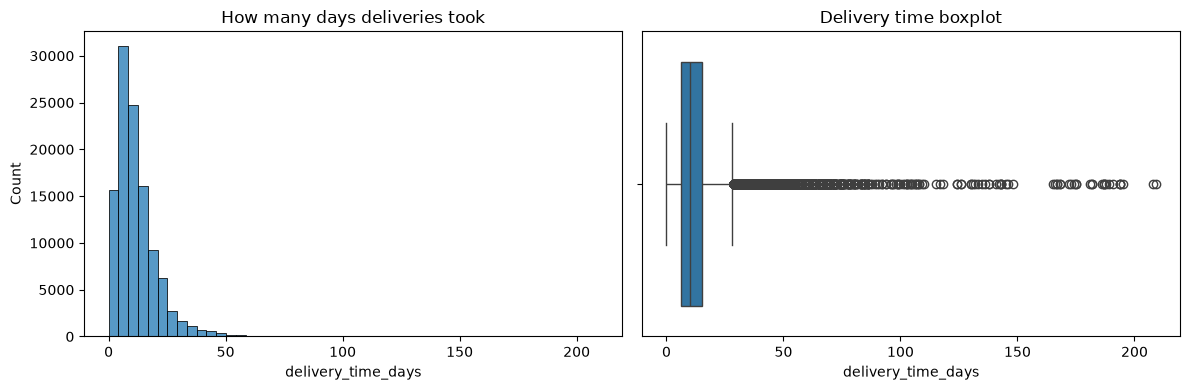

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(analysis['delivery_time_days'].dropna(), bins=50, ax=axes[0])
axes[0].set_title('How many days deliveries took')
sns.boxplot(x=analysis['delivery_time_days'].dropna(), ax=axes[1])
axes[1].set_title('Delivery time boxplot')
plt.tight_layout()
plt.show()

Most orders are delivered within roughly 5–15 days, with a right-skewed tail of slower deliveries stretching out to over a month in some cases. This suggests logistics for most orders is fairly consistent, but a meaningful minority face significant delays.

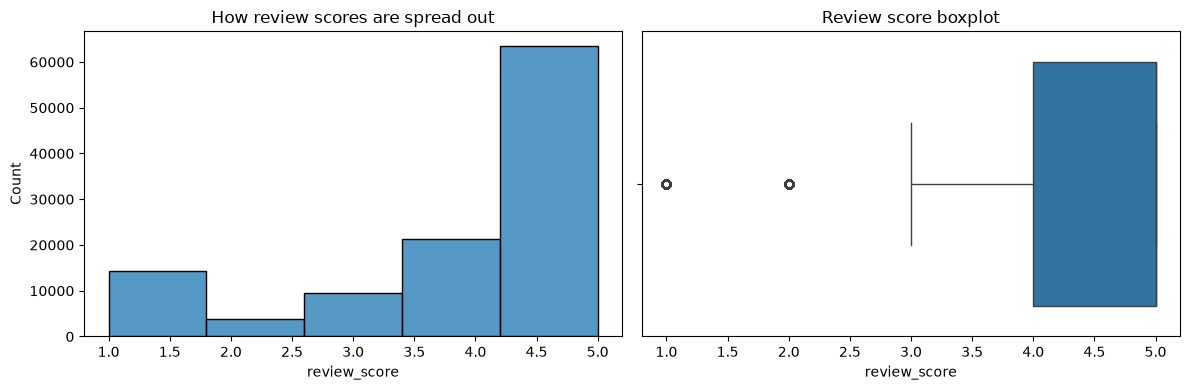

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(analysis['review_score'].dropna(), bins=5, ax=axes[0])
axes[0].set_title('How review scores are spread out')
sns.boxplot(x=analysis['review_score'].dropna(), ax=axes[1])
axes[1].set_title('Review score boxplot')
plt.tight_layout()
plt.show()

Review scores skew heavily positive, with 5-star ratings being the most common by far. This is typical of e-commerce review data. Customers who are satisfied are more likely to leave any review at all, or ratings cluster near the top when service is generally reliable.

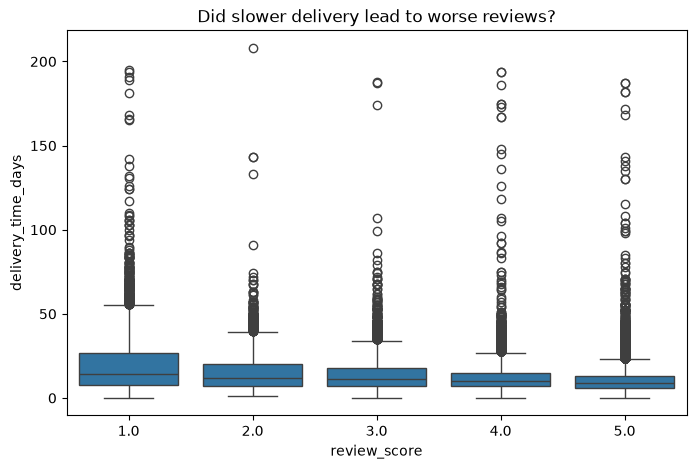

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=analysis, x='review_score', y='delivery_time_days')
plt.title('Did slower delivery lead to worse reviews?')
plt.show()

Lower review scores (1–2 stars) tend to be associated with noticeably longer delivery times compared to higher scores. This suggests slow delivery is a real driver of customer dissatisfaction, not just one factor among many unrelated ones.

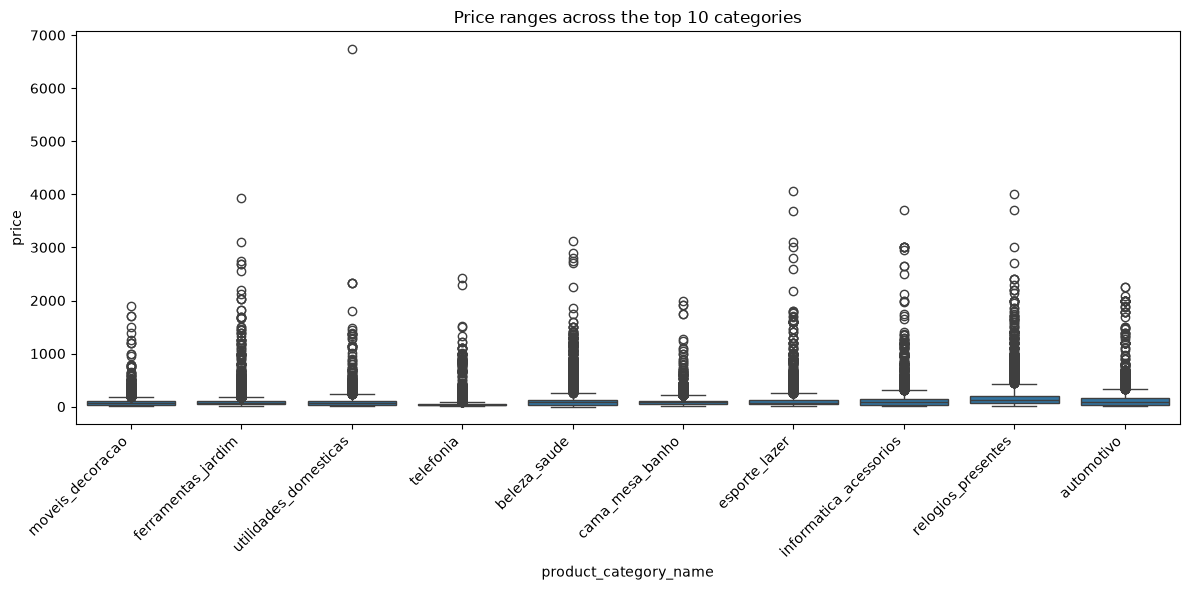

In [16]:
top_categories = analysis['product_category_name'].value_counts().head(10).index
subset = analysis[analysis['product_category_name'].isin(top_categories)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=subset, x='product_category_name', y='price')
plt.xticks(rotation=45, ha='right')
plt.title('Price ranges across the top 10 categories')
plt.tight_layout()
plt.show()

Price ranges vary by category some categories have both higher median prices and wider spread, and some categories  cluster tightly at lower price points. This confirms category is a meaningful driver of price variation.

TASK 2


In [17]:
monthly_orders = analysis.groupby('order_month')['order_id'].nunique().reset_index()
fig = px.line(monthly_orders, x='order_month', y='order_id', title='How order volume changed month by month')
fig.show()

Order volume shows clear growth over the dataset's timeframe, with a sharp jump in 2017. And got a serious decline in 2018.

In [18]:
state_orders = analysis.groupby('customer_state')['order_id'].nunique().reset_index().sort_values('order_id', ascending=False)
fig = px.bar(state_orders, x='customer_state', y='order_id', title='Orders by state')
fig.show()

Order volume is heavily concentrated in a small number of states 'SP' typically dominates Olist's customer base by a wide margin, consistent with it being Brazil's most populous and economically active state. This kind of geographic concentration matters for logistics and delivery time planning.

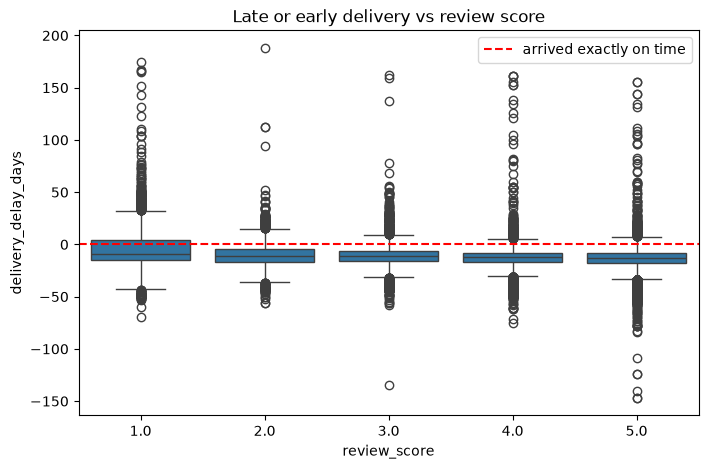

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=analysis, x='review_score', y='delivery_delay_days')
plt.axhline(0, color='red', linestyle='--', label='arrived exactly on time')
plt.legend()
plt.title('Late or early delivery vs review score')
plt.show()

Orders with lower review scores tend to have delivery delay values further above zero, meaning they arrived later than estimated. Orders with 5-star reviews cluster closer to or below zero (arriving on time or early), reinforcing that meeting delivery estimates is closely tied to customer satisfaction.

In [20]:
category_revenue = analysis.groupby('product_category_name')['price'].sum().reset_index()
fig = px.treemap(category_revenue, path=['product_category_name'], values='price', title='Revenue by category, sized by importance')
fig.show()

A handful of categories account for a disproportionate share of total revenue, visible as the largest blocks in the treemap. This kind of concentration is useful for prioritization if a few categories drive most revenue, they deserve the most attention for inventory and marketing decisions.

In [22]:
payment_counts = df['payments']['payment_type'].value_counts().reset_index()
payment_counts.columns = ['payment_type', 'count']
fig = px.pie(payment_counts, names='payment_type', values='count', title='How customers pay')
fig.show()

Credit card is typically the dominant payment method on Olist by a wide margin, with boleto as a distant second. This matters for understanding customer payment friction and checkout design priorities.

In [23]:
seller_orders = analysis.groupby('seller_id')['order_id'].nunique().reset_index()
fig = px.histogram(seller_orders, x='order_id', nbins=50, title='How many orders each seller handles')
fig.show()
print(seller_orders['order_id'].describe())

count    3095.000000
mean       32.313409
std       105.139763
min         1.000000
25%         2.000000
50%         6.000000
75%        21.500000
max      1854.000000
Name: order_id, dtype: float64


The distribution of orders per seller is heavily right-skewed .Most sellers handle only a handful of orders, while a small number of top sellers account for a disproportionately large share of volume. This is a classic long-tail marketplace pattern, meaning platform performance depends heavily on retaining those top sellers.

TASK 3:

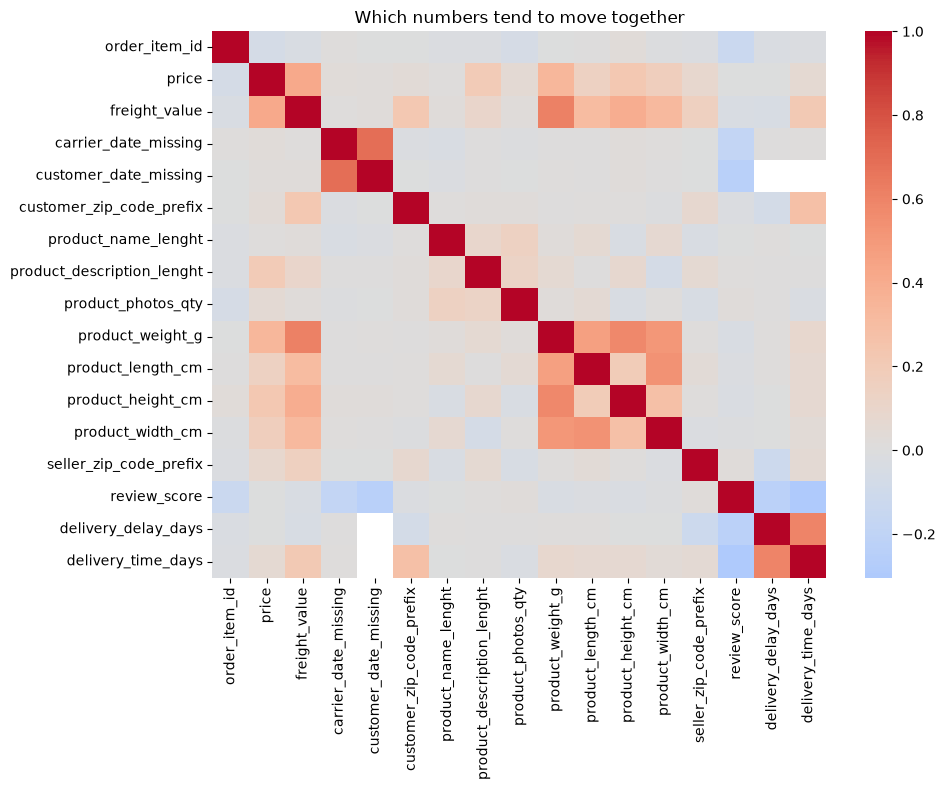

In [24]:
numeric_cols = analysis.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Which numbers tend to move together')
plt.tight_layout()
plt.show()

Most variables show weak correlation with each other, which is expected for a marketplace dataset where price, delivery time, and review score are driven by different underlying factors.

In [25]:
skew_kurt = pd.DataFrame({
    'skewness': analysis[['price', 'freight_value']].skew(),
    'kurtosis': analysis[['price', 'freight_value']].kurt()
})
skew_kurt

,skewness,kurtosis
price,7.929423,121.106233
freight_value,5.639432,59.826472


Price is extremely right-skewed.This is a huge lean toward the low end with a long tail of expensive items dragging the number way up.
Freight is also strongly right-skewed, just slightly less extreme than price.